# Model 1 — Logistic Regression Baseline (Lab 2 code)

This notebook builds the **baseline classifier** for our project.  
Given daily OHLCV data from the Kaggle *Huge Stock Market Dataset*, the goal is to predict whether **tomorrow’s closing price** for a stock will be higher (`Target = 1`, “up”) or lower (`Target = 0`, “down”) than today.

The focus here is on:

- Re-using the **Logistic Regression implementation from Lab 2** (no sklearn classifier).
- Creating a clean, chronologically split dataset.
- Reporting Accuracy, F1 and ROC–AUC as the official baseline for Model 1.


In [1]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


## Kaggle Huge Stock Market Dataset

We use the “Price and volume data for all US stocks & ETFs” dataset by Marjanovic (2016) on Kaggle.  
Each ticker is stored as a separate `.txt` file with daily OHLCV bars.


### 1) Locate dataset files

The raw files are stored as one file per ticker under `../data/raw/Stocks`.  
This cell collects all available `.txt` files so we can loop over tickers in a consistent way.


In [2]:
from pathlib import Path

# Your dataset lives here
DATA_DIR = Path("../data/raw/Stocks")

# collect .txt 
files = list(DATA_DIR.glob("*.txt")) 

print(f"Total files found: {len(files)}")
# peek at the first few
files[:5]


Total files found: 7195


[WindowsPath('../data/raw/Stocks/a.us.txt'),
 WindowsPath('../data/raw/Stocks/aa.us.txt'),
 WindowsPath('../data/raw/Stocks/aaap.us.txt'),
 WindowsPath('../data/raw/Stocks/aaba.us.txt'),
 WindowsPath('../data/raw/Stocks/aac.us.txt')]

### 2) Load a subset of tickers

To keep Model 1 fast and reproducible, we initially load only the first 50 tickers.  
This already gives a large multi-asset panel of daily bars; you can later increase this number if training is still fast enough on your machine.


In [3]:
import pandas as pd

dfs = []
for f in files[:50]:  # take 50 tickers first so it runs fast
    try:
        df = pd.read_csv(f, engine="python")  # detect delimiter automatically
        ticker = f.stem.split('.')[0]         # e.g. "a.us.txt" -> "a"
        df["Ticker"] = ticker
        dfs.append(df)
    except Exception as e:
        print(f"Skipping {f.name}: {e}")

data = pd.concat(dfs, ignore_index=True)
print("Shape:", data.shape)
data.head()


Shape: (141355, 8)


,Date,Open,High,Low,Close,Volume,OpenInt,Ticker
0,1999-11-18,30.713,33.754,27.002,29.702,66277506,0,a
1,1999-11-19,28.986,29.027,26.872,27.257,16142920,0,a
2,1999-11-22,27.886,29.702,27.044,29.702,6970266,0,a
3,1999-11-23,28.688,29.446,27.002,27.002,6332082,0,a
4,1999-11-24,27.083,28.309,27.002,27.717,5132147,0,a


### 3) Preprocess → target + features

Here we:

- Parse dates and sort by `Ticker, Date`.
- Build the binary **Target** label: `1` if next day’s close is higher than today’s, `0` otherwise.
- Engineer a small set of simple technical features (intraday return, normalized range, volume change, short moving averages and returns).
- Drop rows with missing values so that we end up with a clean feature matrix `X` and label vector `y`.


In [4]:
# --- preprocessing
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
data = data.dropna(subset=["Date","Open","High","Low","Close","Volume"]).sort_values(["Ticker","Date"])

# target: next-day up (1) vs down (0) per ticker
data["NextClose"] = data.groupby("Ticker")["Close"].shift(-1)
data = data.dropna(subset=["NextClose"])
data["Target"] = (data["NextClose"] > data["Close"]).astype(int)

# simple features
data["ret_1d"]  = (data["Close"] - data["Open"]) / data["Open"]
data["range"]   = (data["High"] - data["Low"]) / data["Open"]
data["vol_chg"] = data.groupby("Ticker")["Volume"].pct_change().fillna(0)

# short rolling context
for w in [5, 10]:
    data[f"ma_{w}"]  = data.groupby("Ticker")["Close"].transform(lambda s: s.rolling(w, min_periods=1).mean())
    data[f"ret_{w}"] = data.groupby("Ticker")["Close"].transform(lambda s: s.pct_change(w))

feature_cols = ["ret_1d","range","vol_chg","ma_5","ma_10","ret_5","ret_10"]
data = data.dropna(subset=feature_cols).copy()

print("Rows after prep:", len(data))
print("Class balance (1=up):")
print(data["Target"].value_counts(normalize=True).round(3))


Rows after prep: 140805
Class balance (1=up):
Target
0    0.516
1    0.484
Name: proportion, dtype: float64


### 4) Chronological train/test split (avoid leakage)

Financial time series must be split by **time**, not by random shuffling.  
We cut on the 80-th percentile of dates: all earlier observations form the training set, and all later observations form the test set.  
This mimics the real-world situation where we train on the past and evaluate on the future.


In [5]:
# global chronological split using Date quantile
split_date = data["Date"].quantile(0.8)
train_idx = data["Date"] <= split_date
test_idx  = data["Date"] >  split_date

X_train = data.loc[train_idx, feature_cols].to_numpy()
y_train = data.loc[train_idx, "Target"].to_numpy()
X_test  = data.loc[test_idx,  feature_cols].to_numpy()
y_test  = data.loc[test_idx,  "Target"].to_numpy()

X_train.shape, X_test.shape


((112677, 7), (28128, 7))

### 5) Train Logistic Regression (Lab 2 implementation)

In this cell we:

- Standardize the features with `StandardScaler`.
- Use the **Logistic Regression implementation from Lab 2** (gradient descent on the logistic loss) instead of `sklearn.linear_model.LogisticRegression`.
- Clearly mark the block of code that is adapted from the assignment using the required comments:

```python
# Code Assignment starts here
...
# Code Assignment stops here


In [6]:
## Code cell 12 – **Logistic Regression with assignment code**

# 5) Train Logistic Regression (Assignment-based baseline)

# --- Clean NaN / infinite values before scaling
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Code Assignment starts here (Logistic Regression implementation from Lab 2)

def sigmoid(z):
    """Compute sigmoid(z) elementwise for scalar or ndarray."""
    return 1.0 / (1.0 + np.exp(-z))

def compute_cost_logistic(X, y, w, b):
    """Binary cross-entropy cost for logistic regression."""
    m = X.shape[0]
    z = X @ w + b
    h = sigmoid(z)
    eps = 1e-15
    cost = -(1.0 / m) * (
        np.dot(y, np.log(h + eps)) + np.dot(1 - y, np.log(1 - h + eps))
    )
    return cost

def compute_gradient_logistic(X, y, w, b):
    """Gradient of the logistic loss with respect to w and b."""
    m = X.shape[0]
    z = X @ w + b
    h = sigmoid(z)
    error = h - y
    dw = (1.0 / m) * (X.T @ error)
    db = (1.0 / m) * np.sum(error)
    return dw, db

def gradient_descent_logistic(X, y, w_in, b_in, alpha, num_iters, verbose=False):
    """Run gradient descent for logistic regression."""
    w = w_in.copy()
    b = float(b_in)
    J_history = []

    for i in range(num_iters):
        dw, db = compute_gradient_logistic(X, y, w, b)
        w -= alpha * dw
        b -= alpha * db

        if i % 100 == 0 or i == num_iters - 1:
            cost = compute_cost_logistic(X, y, w, b)
            J_history.append(cost)
            if verbose:
                print(f"iteration {i:4d}: cost {cost:.4f}")

    return w, b, J_history

def predict_proba_logistic(X, w, b):
    """Return P(y=1|x) for each row of X."""
    return sigmoid(X @ w + b)

def predict_logistic(X, w, b, threshold=0.5):
    """Return hard class predictions 0/1 given a threshold."""
    return (predict_proba_logistic(X, w, b) >= threshold).astype(int)

# initialize parameters
n_features = X_train_s.shape[1]
w0 = np.zeros(n_features)
b0 = 0.0

alpha = 0.1      # learning rate (can be tuned)
num_iters = 1000 # number of gradient descent iterations

w_trained, b_trained, J_hist = gradient_descent_logistic(
    X_train_s, y_train, w0, b0, alpha, num_iters, verbose=False
)

# predictions on test set
y_prob = predict_proba_logistic(X_test_s, w_trained, b_trained)
y_pred = predict_logistic(X_test_s, w_trained, b_trained, threshold=0.5)

# Code Assignment stops here


### 6) Evaluate + plots

Finally we compute Accuracy, F1-score and ROC–AUC on the test period, print the classification report, and visualize:

- the confusion matrix, and  
- the distribution of predicted probabilities for the positive class (“up”).

These numbers and plots are what we will report in the milestone and final poster for Model 1.


Accuracy: 0.5063
F1 Score: 0.104
ROC-AUC : 0.521

Classification Report:
               precision    recall  f1-score   support

           0     0.5069    0.9429    0.6593     14250
           1     0.4975    0.0581    0.1040     13878

    accuracy                         0.5063     28128
   macro avg     0.5022    0.5005    0.3817     28128
weighted avg     0.5023    0.5063    0.3853     28128



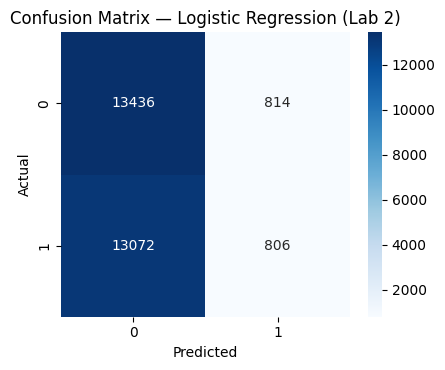

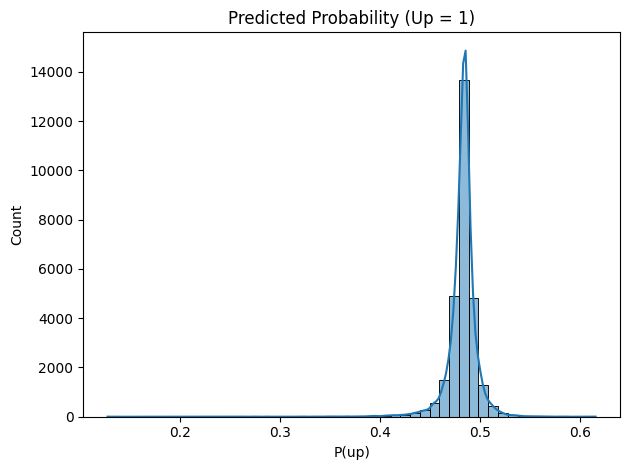

In [7]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns, matplotlib.pyplot as plt

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5,3.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression (Lab 2)")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()

sns.histplot(y_prob, bins=50, kde=True)
plt.title("Predicted Probability (Up = 1)")
plt.xlabel("P(up)")
plt.tight_layout()
plt.show()
